# Improved HOG + SVM Vehicle Detection

This notebook is tuned to improve both detection quality and runtime on your dataset.
It reports Mean IoU, Precision, Recall, mAP@0.50, mAP@0.50:0.95, visualization, and inference time.

In [3]:
import time
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

random.seed(42)
np.random.seed(42)

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
ROOT = Path("/content/drive/MyDrive/CS231/CS231_VehicleDetection/")
DATA_ROOT = ROOT / 'data' / 'main'
TRAIN_IMG_DIR = DATA_ROOT / 'train' / 'images'
TRAIN_LBL_DIR = DATA_ROOT / 'train' / 'labels'
VAL_IMG_DIR = DATA_ROOT / 'valid' / 'images'
VAL_LBL_DIR = DATA_ROOT / 'valid' / 'labels'
TEST_IMG_DIR = DATA_ROOT / 'test' / 'images'
TEST_LBL_DIR = DATA_ROOT / 'test' / 'labels'
MODEL_PATH = ROOT / "models"

CLASS_NAMES = ['bus', 'car', 'motorbike', 'truck']
NUM_CLASSES = len(CLASS_NAMES)
BG_CLASS = NUM_CLASSES

for p in [TRAIN_IMG_DIR, TRAIN_LBL_DIR, VAL_IMG_DIR, VAL_LBL_DIR, TEST_IMG_DIR, TEST_LBL_DIR]:
    if not p.exists():
        raise FileNotFoundError(f'Missing expected path: {p}')

print('Dataset paths OK')

Dataset paths OK


In [6]:
PATCH_SIZE = (48, 48)
NEG_PER_IMAGE = 50
NEG_IOU_MAX = 0.3
HARD_NEG_PER_IMAGE = 15
MAX_TRAIN_IMAGES = None

# OpenCV HOG: faster than skimage HOG for this use case
HOG_BINS = 9
PIX_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)

# Detection
WINDOW_STRIDE = 32
Y_SEARCH_RANGE = (0.2, 0.90)
NMS_IOU_THRESHOLD = 0.35
SCORE_THRESHOLD = 0.5
TOPK_PER_CLASS_PER_IMAGE = 40

print('Hyperparameters set')

Hyperparameters set


In [7]:
# Hàm kiểm tra định dạng ảnh
def image_files(img_dir):
    return sorted([p for p in img_dir.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}])

# Lấy đường dẫn label từ đường dẫn ảnh
def label_path_for_image(lbl_dir, img_path):
    return lbl_dir / (img_path.stem + '.txt')

# Chuyển annotation từ format YOLO sang XYXY
def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2.0) * img_w
    y1 = (yc - h / 2.0) * img_h
    x2 = (xc + w / 2.0) * img_w
    y2 = (yc + h / 2.0) * img_h
    return [x1, y1, x2, y2]

# Chuẩn hóa bouding box cho nằm trong ảnh
def clip_box_xyxy(box, img_w, img_h):
    x1, y1, x2, y2 = box
    x1 = float(np.clip(x1, 0, img_w - 1))
    y1 = float(np.clip(y1, 0, img_h - 1))
    x2 = float(np.clip(x2, 0, img_w - 1))
    y2 = float(np.clip(y2, 0, img_h - 1))
    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2, y2]

# Đọc các annotations để lấy thông tin về ảnh và label
def read_annotations(img_dir, lbl_dir):
    records = []
    for img_path in image_files(img_dir):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        boxes = []
        labels = []
        lbl = label_path_for_image(lbl_dir, img_path)
        if lbl.exists():
            for line in lbl.read_text(encoding='utf-8').splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls_id, xc, yc, bw, bh = parts
                cls_id = int(float(cls_id))
                if cls_id < 0 or cls_id >= NUM_CLASSES:
                    continue
                box = yolo_to_xyxy(float(xc), float(yc), float(bw), float(bh), w, h)
                box = clip_box_xyxy(box, w, h)
                if box is None:
                    continue
                boxes.append(box)
                labels.append(cls_id)

        records.append({
            'image_path': img_path,
            'width': w,
            'height': h,
            'boxes': np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32),
            'labels': np.array(labels, dtype=np.int32) if labels else np.zeros((0,), dtype=np.int32),
        })
    return records

train_records = read_annotations(TRAIN_IMG_DIR, TRAIN_LBL_DIR)
val_records = read_annotations(VAL_IMG_DIR, VAL_LBL_DIR)
test_records = read_annotations(TEST_IMG_DIR, TEST_LBL_DIR)

print(f'Train: {len(train_records)} | Val: {len(val_records)} | Test: {len(test_records)}')

Train: 800 | Val: 100 | Test: 100


In [8]:
# Tính IoU
def compute_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

# Tìm IoU lớn nhất
def max_iou_with_boxes(box, gt_boxes):
    if len(gt_boxes) == 0:
        return 0.0
    return max(compute_iou(box, g) for g in gt_boxes)

# Cắt vùng trong ảnh để xử lí
def crop_and_resize(img, box, out_size=PATCH_SIZE):
    x1, y1, x2, y2 = [int(round(v)) for v in box]
    patch = img[y1:y2, x1:x2]
    if patch.size == 0:
        return None
    return cv2.resize(patch, out_size, interpolation=cv2.INTER_AREA)

In [9]:
# OpenCV HOG descriptor (fast)
win_size = PATCH_SIZE
cell_size = PIX_PER_CELL
block_size = (CELLS_PER_BLOCK[0] * cell_size[0], CELLS_PER_BLOCK[1] * cell_size[1])
block_stride = (cell_size[0], cell_size[1])

# Khởi tạo bộ mô tả OpenCV HOGDescriptor (Tốc độ xử lý rất nhanh bằng C++)
HOG = cv2.HOGDescriptor(
    win_size,        # winSize
    block_size,      # blockSize
    block_stride,    # blockStride
    cell_size,       # cellSize
    HOG_BINS,        # nbins
)

def extract_feature(patch_bgr):
    """
    Trích xuất đặc trưng HOG chuẩn: Grayscale -> Chuẩn hóa -> Tính HOG
    """
    # Bước 1: Chuyển sang ảnh xám (Grayscale)
    gray = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2GRAY)

    # Bước 2: Chuẩn hóa cường độ sáng (Min-Max Normalization về khoảng 0 - 255)
    # Bước này giúp giảm thiểu tác động của việc ảnh quá tối hoặc quá sáng
    gray_normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

    # Bước 3: Trích xuất và trải phẳng vector HOG
    hog_vec = HOG.compute(gray_normalized).reshape(-1)

    return hog_vec.astype(np.float32)

In [10]:
def sample_negative_boxes(record, n, max_iou=0.08, max_trials=400):
    """
    Hàm lấy mẫu ngẫu nhiên các ô vuông làm nhãn âm (Background/Nền).
    Đảm bảo các ô này không trùng lặp quá nhiều với vật thể thật (Ground Truth).
    """
    w, h = record['width'], record['height']
    gt = record['boxes']
    out = []
    scales = [0.75, 1.0, 1.25, 1.5, 1.8] # Các tỷ lệ phóng to/thu nhỏ của ô ảnh mẫu

    t = 0
    # Vòng lặp dừng khi lấy đủ số lượng mẫu 'n' HOẶC vượt quá số lần thử tối đa 'max_trials'
    while len(out) < n and t < max_trials:
        t += 1
        s = random.choice(scales) # Chọn ngẫu nhiên một tỷ lệ kích thước
        bw = int(PATCH_SIZE[0] * s)
        bh = int(PATCH_SIZE[1] * s)

        # Bỏ qua nếu kích thước ô mẫu lớn hơn cả kích thước bức ảnh gốc
        if bw >= w or bh >= h:
            continue

        # Chọn tọa độ góc trên bên trái ngẫu nhiên trong phạm vi hợp lệ của ảnh
        x1 = random.randint(0, w - bw - 1)
        # Bắt đầu quét y từ 15% chiều cao ảnh trở xuống (thường để bỏ qua vùng bầu trời)
        y1 = random.randint(int(h * 0.15), h - bh - 1)

        b = [x1, y1, x1 + bw, y1 + bh] # Tọa độ bounding box ngẫu nhiên [x1, y1, x2, y2]

        # Kiểm tra độ chồng chéo (IoU) lớn nhất giữa ô ngẫu nhiên này với tất cả các vật thể thật
        # Nếu IoU nhỏ hơn ngưỡng cho phép (max_iou), chứng tỏ đây là vùng nền sạch -> Giữ lại
        if max_iou_with_boxes(b, gt) <= max_iou:
            out.append(b)

    return out

def build_train_features(records, max_images=None):
    """
    Hàm duyệt qua danh sách ảnh để cắt vùng dữ liệu, trích xuất đặc trưng
    và đóng gói thành tập dữ liệu huấn luyện X (đặc trưng) và y (nhãn).
    """
    X, y = [], []
    # Giới hạn số lượng ảnh xử lý nếu cấu hình max_images được đặt
    use = records if max_images is None else records[:max_images]

    for rec in use:
        # Đọc ảnh từ đường dẫn
        img = cv2.imread(str(rec['image_path']))
        if img is None: # Bỏ qua nếu ảnh bị lỗi hoặc không tồn tại
            continue

        # --- PHẦN 1: TRÍCH XUẤT NHÃN DƯƠNG (CÁC VẬT THỂ THẬT) ---
        for box, cls_id in zip(rec['boxes'], rec['labels']):
            p = crop_and_resize(img, box) # Cắt vùng vật thể và resize về kích thước chuẩn
            if p is None:
                continue
            X.append(extract_feature(p))  # Trích xuất đặc trưng (HOG/Color...) rồi thêm vào tập X
            y.append(int(cls_id))         # Thêm nhãn của vật thể vào tập y

        # --- PHẦN 2: TRÍCH XUẤT NHÃN ÂM (BACKGROUND / NỀN TRỐNG) ---
        # Gọi hàm lấy mẫu ngẫu nhiên các ô nền trên chính bức ảnh này
        for b in sample_negative_boxes(rec, NEG_PER_IMAGE, max_iou=NEG_IOU_MAX):
            p = crop_and_resize(img, b) # Cắt vùng nền và resize về kích thước chuẩn
            if p is None:
                continue
            X.append(extract_feature(p))  # Trích xuất đặc trưng của vùng nền trống
            y.append(BG_CLASS)            # Gắn nhãn lớp nền (ví dụ: lớp 0 hoặc lớp cuối cùng)

    # Chuyển đổi danh sách dữ liệu thành mảng NumPy định dạng chuẩn để nạp vào mô hình học máy
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int32)

# --- BẮT ĐẦU CHẠY QUY TRÌNH CHUẨN BỊ DỮ LIỆU HUẤN LUYỆN ---

# Gộp chung tập train và tập validation lại thành một bể chứa dữ liệu mẫu để trích xuất (nếu cần)
train_pool = train_records + val_records

# Thực hiện xây dựng tập dữ liệu đặc trưng X_train và y_train
X_train, y_train = build_train_features(train_pool, max_images=MAX_TRAIN_IMAGES)

# In ra kích thước của tập dữ liệu đặc trưng (Số lượng mẫu x Chiều dài vector đặc trưng)
print('Train feature shape:', X_train.shape)

# Vòng lặp thống kê số lượng mẫu của từng lớp (bao gồm các lớp vật thể và lớp nền)
for i in range(NUM_CLASSES + 1):
    # Xác định tên hiển thị: Nếu là lớp cuối cùng thì đặt là 'background', ngược lại lấy từ mảng danh mục
    name = CLASS_NAMES[i] if i < NUM_CLASSES else 'background'
    # Tính tổng số mẫu thuộc về lớp i hiện tại và in ra màn hình căn lề phải cho đẹp
    print(f'{name:>10}: {(y_train == i).sum()}')

Train feature shape: (55301, 900)
       bus: 332
       car: 3503
 motorbike: 5618
     truck: 848
background: 45000


In [11]:
def fit_model(X, y, C=1.0):
    """
    Hàm huấn luyện mô hình SVM tuyến tính (LinearSVC) kết hợp chuẩn hóa dữ liệu.
    Tự động tối ưu tham số 'dual' dựa trên kích thước ma trận đặc trưng để tăng tốc độ.
    """
    # 1. Khởi tạo và thực hiện chuẩn hóa dữ liệu về phân phối chuẩn (mean=0, var=1)
    # Bước này giúp SVM hội tụ nhanh hơn và không bị lệch bởi các đặc trưng có giá trị lớn
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # 2. Tự động tối ưu hóa toán toán giải (Tham số dual)
    # Lấy ra: n_samples (số lượng dòng/mẫu), n_features (số lượng cột/đặc trưng HOG)
    n_samples, n_features = X.shape

    # NOTE VỀ DUAL:
    # Theo tài liệu scikit-learn, nếu số lượng mẫu (dòng) LỚN HƠN số lượng đặc trưng (cột),
    # ta nên đặt dual=False (giải bài toán gốc) để tránh mô hình bị treo hoặc chạy cực kỳ chậm.
    # Ngược lại, nếu số mẫu ít hơn số đặc trưng, đặt dual=True (giải bài toán đối ngẫu).
    is_dual = n_samples < n_features

    # 3. Khởi tạo mô hình SVM tuyến tính với các cấu hình tối ưu
    clf = LinearSVC(
        C=C,           # Tham số phạt lỗi ranh giới biên (Soft-margin control)
        class_weight='balanced', # Tự động cân bằng trọng số vì tập mẫu âm (nền) luôn nhiều hơn mẫu dương
        dual=is_dual,
        max_iter=30000
    )

    # 4. Tiến hành bấm giờ và huấn luyện mô hình
    t0 = time.perf_counter()
    clf.fit(Xs, y)
    dt = time.perf_counter() - t0

    return scaler, clf, dt


In [12]:

# Data-driven window scales from GT box size stats
def estimate_scales(records):
    """
    Hàm tự động tính toán các tỷ lệ (scales) cho cửa sổ quét (sliding window)
    dựa trên thống kê kích thước thực tế của các vật thể thật (Ground Truth) trong tập dữ liệu.
    """
    ratios = [] # Danh sách chứa tỷ lệ kích thước của từng vật thể so với PATCH_SIZE chuẩn

    # Duyệt qua từng bức ảnh trong tập dữ liệu
    for rec in records:
        # Duyệt qua từng bounding box của vật thể thật trong ảnh đó
        for b in rec['boxes']:
            # Tính chiều rộng (bw) và chiều cao (bh) của vật thể
            # Hàm max(1.0, ...) đảm bảo kích thước không bị bằng 0 (tránh lỗi chia cho 0)
            bw = max(1.0, b[2] - b[0])
            bh = max(1.0, b[3] - b[1])

            # Tính toán xem vật thể lớn gấp bao nhiêu lần so với kích thước PATCH_SIZE gốc.
            # Lấy giá trị lớn nhất giữa tỉ lệ chiều rộng và chiều cao để đảm bảo cửa sổ bao trọn được vật thể.
            ratios.append(max(bw / PATCH_SIZE[0], bh / PATCH_SIZE[1]))

    # Trường hợp tập dữ liệu trống hoặc không tìm thấy vật thể nào, trả về danh sách tỷ lệ mặc định an toàn
    if len(ratios) == 0:
        return [0.85, 1.0, 1.2, 1.5]

    # Sử dụng hàm phân vị (Quantile) để chọn ra 5 mốc đại diện tương ứng với các kích cỡ vật thể:
    # Rất nhỏ (15%), nhỏ (35%), trung bình (55%), lớn (75%), và rất lớn (90%) xuất hiện trong tập dữ liệu
    q = np.quantile(np.array(ratios), [0.15, 0.35, 0.55, 0.75, 0.9])

    # Xử lý chuẩn hóa danh sách tỷ lệ:
    # 1. np.clip(v, 0.65, 2.6): Giới hạn tỷ lệ scale chỉ nằm trong khoảng an toàn từ 0.65 đến 2.6 lần PATCH_SIZE
    # 2. set(...): Loại bỏ các giá trị scale bị trùng lặp (nếu có)
    # 3. sorted(...): Sắp xếp các tỷ lệ theo thứ tự tăng dần từ nhỏ đến lớn
    scales = sorted(set([float(np.clip(v, 0.65, 2.6)) for v in q]))

    return scales

# --- THỰC THI TÍNH TOÁN CÁC TỶ LỆ CỬA SỔ QUÉT ---

# Gọi hàm phân tích trên bể dữ liệu huấn luyện (train_pool) để lấy ra các tỷ lệ tối ưu nhất
WINDOW_SCALES = estimate_scales(train_pool)

# In danh sách các tỷ lệ scale tối ưu được hệ thống tự động tính toán ra màn hình
print('WINDOW_SCALES:', WINDOW_SCALES)

WINDOW_SCALES: [0.65, 0.8854166865348816, 1.3958333730697632, 2.0625, 2.6]


In [13]:
def nms(boxes, scores, iou_thr=0.4):
    """
    Hàm Non-Maximum Suppression (NMS) - Khử cực đại cục bộ.
    Mục đích: Loại bỏ các ô nhận diện bị trùng lặp đè lên nhau trên cùng một vật thể,
    chỉ giữ lại ô có điểm tin cậy (score) cao nhất.
    """
    if len(boxes) == 0:
        return []

    # Chuyển đổi dữ liệu đầu vào thành mảng NumPy định dạng số thực để tính toán toán học
    boxes = np.asarray(boxes, dtype=np.float32)
    scores = np.asarray(scores, dtype=np.float32)

    # Sắp xếp các ô theo thứ tự điểm số giảm dần (từ cao xuống thấp)
    # argsort()[::-1] trả về mảng các chỉ số (indices) của các phần tử sau khi sắp xếp
    order = scores.argsort()[::-1]
    keep = []  # Danh sách lưu các chỉ số của những ô được giữ lại cuối cùng

    # Vòng lặp quét qua danh sách các ô cho đến khi không còn ô nào cần xử lý
    while order.size > 0:
        i = order[0]  # Lấy ra chỉ số của ô có điểm số cao nhất hiện tại
        keep.append(i)  # Chắc chắn giữ lại ô này

        if order.size == 1:  # Nếu chỉ còn duy nhất 1 ô thì dừng vòng lặp
            break

        rest = order[1:]  # Danh sách tất cả các ô còn lại để so sánh với ô 'i'

        # Tính toán IoU (độ chồng chéo) giữa ô 'i' đang xét với từng ô còn lại trong danh sách 'rest'
        ious = np.array(
            [compute_iou(boxes[i], boxes[j]) for j in rest], dtype=np.float32
        )

        # CHÚ Ý: Chỉ giữ lại những ô có độ chồng chéo (IoU) ÍT HƠN ngưỡng iou_thr đối với ô 'i'
        # Những ô có IoU >= iou_thr được coi là bị trùng lặp (cùng nhận diện 1 vật thể) và sẽ bị loại bỏ
        order = rest[ious < iou_thr]

    return keep


def sliding_windows(img_w, img_h, scales, stride):
    """
    Hàm sinh danh sách các tọa độ cửa sổ trượt (Sliding Windows) trên toàn bộ bức ảnh.
    Cửa sổ sẽ trượt theo hàng ngang và hàng dọc dựa trên bước nhảy (stride) và các tỷ lệ (scales).
    """
    # Xác định vùng giới hạn tìm kiếm theo chiều dọc (trục Y) dựa trên tỷ lệ cấu hình trước
    # Ví dụ: Bỏ qua 15% bầu trời ở trên hoặc phần mui xe ở dưới để tăng tốc độ quét
    ys = int(img_h * Y_SEARCH_RANGE[0])
    ye = int(img_h * Y_SEARCH_RANGE[1])
    windows = []  # Danh sách chứa tọa độ của toàn bộ các cửa sổ sinh ra

    # Duyệt qua từng tỷ lệ kích thước cửa sổ (đã được tối ưu từ bước thống kê trước đó)
    for s in scales:
        bw = int(PATCH_SIZE[0] * s)  # Chiều rộng thực tế của cửa sổ tại scale hiện tại
        bh = int(PATCH_SIZE[1] * s)  # Chiều cao thực tế của cửa sổ tại scale hiện tại

        # Bỏ qua scale này nếu kích thước cửa sổ vượt quá kích thước của ảnh gốc
        if bw >= img_w or bh >= img_h:
            continue

        # Điểm dừng an toàn cho vòng lặp Y để đảm bảo cửa sổ không bị trượt ra ngoài rìa dưới của vùng tìm kiếm
        y_stop = max(ys + 1, ye - bh)

        # Vòng lặp trượt theo chiều dọc (Trục Y)
        for y in range(ys, y_stop, stride):
            # Vòng lặp trượt theo chiều ngang (Trục X)
            for x in range(0, img_w - bw, stride):
                # Lưu tọa độ cửa sổ dạng [x1, y1, x2, y2] vào danh sách
                windows.append([x, y, x + bw, y + bh])

    return windows


def detect_in_image(img, scaler, clf):
    h, w = img.shape[:2]
    # Sinh cửa sổ trượt đa quy mô
    windows = sliding_windows(w, h, WINDOW_SCALES, WINDOW_STRIDE)

    feats = []
    valid_boxes = []

    # 1. Gom toàn bộ đặc trưng thô của một ảnh vào list
    for box in windows:
        x1, y1, x2, y2 = box
        patch = img[y1:y2, x1:x2]
        if patch.size == 0:
            continue
        patch_resized = cv2.resize(patch, PATCH_SIZE)

        # Chỉ trích xuất đặc trưng thô
        feats.append(extract_feature(patch_resized))
        valid_boxes.append(box)

    if len(feats) == 0:
        return []

    # 2. CHUYỂN CHUẨN HÓA VÀ DỰ ĐOÁN THÀNH BATCH
    X = scaler.transform(np.asarray(feats, dtype=np.float32))
    scores_mat = clf.decision_function(X) # Hàm tối ưu hóa luồng

    # 3. Lọc kết quả sau khi dự đoán hàng loạt
    preds = []
    for idx, row in enumerate(scores_mat):
        cls_id = int(np.argmax(row))
        score = float(row[cls_id])

        if cls_id < NUM_CLASSES and score >= SCORE_THRESHOLD:
            preds.append({
                'box': valid_boxes[idx],
                'score': score,
                'label': cls_id
            })

    # Extract boxes and scores from the filtered predictions for NMS
    pred_boxes = [p['box'] for p in preds]
    pred_scores = [p['score'] for p in preds]

    # Chạy NMS lọc trùng
    keep = nms(pred_boxes, pred_scores, NMS_IOU_THRESHOLD)

    # Return only the predictions that were kept by NMS
    return [preds[i] for i in keep]

In [14]:
import numpy as np
import time
import cv2

# --- HÀM TỐI ƯU: TÍNH AP CHO TẤT CẢ CÁC NGƯỠNG IOU CÙNG LÚC ---
def evaluate_class_all_thrs(preds_by_image, gts_by_image, class_id, thrs):
    """
    Tính AP@0.5 và AP@0.5:0.95 chỉ trong MỘT lượt duyệt duy nhất.
    Đồng thời trả về số lượng TP, FP thực tế tại ngưỡng 0.5 để tính nhanh Precision/Recall.
    """
    gt_total = 0
    gts_cls_by_img = {}

    # Khởi tạo cấu trúc dữ liệu matched cho từng ngưỡng IoU
    # matched_dict[iou_thr][img_id] = mảng boolean gts
    matched_dict = {t: {} for t in thrs}

    for img_id, gts in gts_by_image.items():
        pure_gts = [g for g in gts if g['label'] == class_id]
        gt_total += len(pure_gts)
        gts_cls_by_img[img_id] = pure_gts

        for t in thrs:
            matched_dict[t][img_id] = np.zeros(len(pure_gts), dtype=bool)

    # Gom và sắp xếp dự đoán theo điểm số giảm dần (chỉ làm 1 lần)
    pred_list = []
    for img_id, preds in preds_by_image.items():
        for p in preds:
            if p['label'] == class_id:
                pred_list.append((img_id, p['box']))

    if len(pred_list) == 0:
        return 0.0, 0.0, 0, 0, gt_total

    # Đánh giá tuần tự các dự đoán từ cao xuống thấp
    num_preds = len(pred_list)
    tps_matrix = {t: np.zeros(num_preds, dtype=np.float32) for t in thrs}
    fps_matrix = {t: np.zeros(num_preds, dtype=np.float32) for t in thrs}

    for i, (img_id, pb) in enumerate(pred_list):
        cls_gts = gts_cls_by_img[img_id]
        if len(cls_gts) == 0:
            for t in thrs:
                fps_matrix[t][i] = 1
            continue

        # Tính toán IoU một lần duy nhất cho ô đoán này với các GT trong ảnh
        ious = np.array([compute_iou(pb, g['box']) for g in cls_gts], dtype=np.float32)
        max_iou_idx = np.argmax(ious)
        best_iou = float(ious[max_iou_idx])

        # Xét duyệt qua từng ngưỡng IoU độc lập
        for t in thrs:
            if best_iou >= t and not matched_dict[t][img_id][max_iou_idx]:
                tps_matrix[t][i] = 1
                matched_dict[t][img_id][max_iou_idx] = True
            else:
                fps_matrix[t][i] = 1

    # Tính toán AP cho từng ngưỡng dựa trên mảng lũy kế
    aps = []
    tp_at_05, fp_at_05 = 0, 0

    for t in thrs:
        tp_c = np.cumsum(tps_matrix[t])
        fp_c = np.cumsum(fps_matrix[t])

        # Lưu lại thống kê thực tế tại ngưỡng 0.5 để tính Precision/Recall tổng
        if abs(t - 0.5) < 1e-4 and len(tp_c) > 0:
            tp_at_05 = int(tp_c[-1])
            fp_at_05 = int(fp_c[-1])

        recall_curve = tp_c / max(gt_total, 1)
        precision_curve = tp_c / np.maximum(tp_c + fp_c, 1e-9)

        mrec = np.concatenate(([0.0], recall_curve, [1.0]))
        mpre = np.concatenate(([0.0], precision_curve, [0.0]))

        for j in range(mpre.size - 1, 0, -1):
            mpre[j - 1] = max(mpre[j - 1], mpre[j])

        idx = np.where(mrec[1:] != mrec[:-1])[0]
        ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))
        aps.append(ap)

    ap50 = aps[0] # Vì thrs[0] luôn là 0.5
    ap5095 = float(np.mean(aps))

    return ap50, ap5095, tp_at_05, fp_at_05, gt_total


# --- HÀM 2: ĐÁNH GIÁ TOÀN BỘ DATASET ĐÃ ĐƯỢC TỐI ƯU TỐC ĐỘ ---
def evaluate_dataset(records, scaler, clf):
    preds_by_image = {}
    gts_by_image = {}
    infer_times = []
    img_iou_list = []

    # VÒNG LẶP 1: Chạy suy luận (Inference) và thống kê IoU thô
    for i, rec in enumerate(records):
        img = cv2.imread(str(rec['image_path']))
        if img is None:
            continue

        t0 = time.perf_counter()
        preds = detect_in_image(img, scaler, clf)
        infer_times.append(time.perf_counter() - t0)

        preds_by_image[i] = preds
        gts = [{'box': b.tolist(), 'label': int(l)} for b, l in zip(rec['boxes'], rec['labels'])]
        gts_by_image[i] = gts

        # Tính Mean IoU thô nhanh
        best_ious = []
        for g in gts:
            same = [p for p in preds if p['label'] == g['label']]
            if not same:
                best_ious.append(0.0)
            else:
                best_ious.append(max(compute_iou(g['box'], p['box']) for p in same))
        if best_ious:
            img_iou_list.append(float(np.mean(best_ious)))

    # VÒNG LẶP 2: Tính toán mAP siêu tốc & Trích xuất PR cùng lúc
    ap50s = []
    ap5095s = []
    thrs = np.arange(0.5, 0.96, 0.05) # [0.5, 0.55, ..., 0.95]

    total_tp_at_05 = 0
    total_fp_at_05 = 0
    total_gt_count = 0

    for c in range(NUM_CLASSES):
        # Gọi hàm xử lý gộp duy nhất 1 lần cho mỗi Class
        ap50, ap5095, tp_05, fp_05, gt_cnt = evaluate_class_all_thrs(
            preds_by_image, gts_by_image, c, thrs
        )
        ap50s.append(ap50)
        ap5095s.append(ap5095)

        total_tp_at_05 += tp_05
        total_fp_at_05 += fp_05
        total_gt_count += gt_cnt

    # Tính Precision / Recall đại diện thực tế mà không cần chạy lại vòng lặp lồng IoU
    actual_precision = total_tp_at_05 / max((total_tp_at_05 + total_fp_at_05), 1e-9)
    actual_recall = total_tp_at_05 / max(total_gt_count, 1)

    # Tính toán FPS
    total_images_processed = len(infer_times)
    total_inference_time_seconds = sum(infer_times)
    fps = total_images_processed / total_inference_time_seconds if total_inference_time_seconds > 0 else 0.0

    return {
        'mean_iou': float(np.mean(img_iou_list)) if img_iou_list else 0.0,
        'precision': float(actual_precision),
        'recall': float(actual_recall),
        'mAP50': float(np.mean(ap50s)) if ap50s else 0.0,
        'mAP50_95': float(np.mean(ap5095s)) if ap5095s else 0.0,
        'avg_inference_time_ms': 1000.0 * float(np.mean(infer_times)) if infer_times else 0.0,
        'fps': float(fps),
        'preds_by_image': preds_by_image,
        'gts_by_image': gts_by_image,
    }

In [15]:
# BƯỚC 1: Huấn luyện mô hình vòng 1 với dữ liệu ngẫu nhiên ban đầu
# (Giả sử bạn đã có X_train_raw và y_train_raw ban đầu)
scaler, svm_clf, t_init = fit_model(X_train, y_train, C=0.1)
print(f"Vòng 1 hoàn tất ({t_init:.2f}s). Tiến hành quét lỗi...")


Vòng 1 hoàn tất (173.59s). Tiến hành quét lỗi...


In [16]:
import joblib

# Tạo một dictionary đóng gói tất cả các thành phần cốt lõi
model_artifacts = {
    'scaler': scaler,
    'clf': svm_clf,
    'hyperparameters': {
        'PATCH_SIZE': PATCH_SIZE,
        'HOG_BINS': HOG_BINS,
        'PIX_PER_CELL': PIX_PER_CELL,
        'CELLS_PER_BLOCK': CELLS_PER_BLOCK,

    }
}

# Lưu thành một file duy nhất
joblib.dump(model_artifacts, f'{MODEL_PATH}/best_hog_svm.pkl')
print("Đã lưu mô hình thành công!")

Đã lưu mô hình thành công!


### Hard-Negative Mining Implementation

Hard-negative mining is a crucial step to improve the performance of HOG+SVM detectors. The basic idea is to find background patches that the SVM classifier incorrectly labels as objects (false positives) and then retrain the SVM with these 'hard' examples. This helps the model learn to better discriminate between objects and complex background features.

In [17]:
def scan_image_for_hard_negatives(record, scaler, clf, max_iou=NEG_IOU_MAX):
    """
    Quét một ảnh để tìm các trường hợp âm tính 'khó' (hard negatives).
    Đây là những vùng nền mà mô hình hiện tại dự đoán SAI là vật thể.
    """
    img = cv2.imread(str(record['image_path']))
    if img is None:
        return []

    h, w = img.shape[:2]
    windows = sliding_windows(w, h, WINDOW_SCALES, WINDOW_STRIDE)

    hard_neg_patches = []

    # Trích xuất đặc trưng cho tất cả các cửa sổ cùng lúc
    all_feats = []
    for box in windows:
        x1, y1, x2, y2 = box
        patch = img[y1:y2, x1:x2]
        if patch.size == 0:
            continue
        patch_resized = cv2.resize(patch, PATCH_SIZE)
        all_feats.append(extract_feature(patch_resized))

    if not all_feats:
        return []

    # Dự đoán trên tất cả các đặc trưng đã được chuẩn hóa
    X_windows = scaler.transform(np.asarray(all_feats, dtype=np.float32))
    scores_mat = clf.decision_function(X_windows)

    # Kiểm tra từng dự đoán
    for i, row in enumerate(scores_mat):
        cls_id = int(np.argmax(row))
        score = float(row[cls_id])
        box = windows[i]

        # Nếu mô hình dự đoán là vật thể (cls_id < NUM_CLASSES) VÀ score đủ cao
        # VÀ vùng này không chồng lấn đáng kể với bất kỳ vật thể thật nào (là nền trống)
        if cls_id < NUM_CLASSES and score >= SCORE_THRESHOLD and max_iou_with_boxes(box, record['boxes']) <= max_iou:
            # Vùng này là một false positive -> hard negative
            hard_neg_patches.append(box)

    return random.sample(hard_neg_patches, min(HARD_NEG_PER_IMAGE, len(hard_neg_patches)))

In [18]:
def build_hard_negative_dataset(records, scaler, clf, max_images=None):
    """
    Xây dựng tập dữ liệu hard negatives bằng cách quét qua một tập hợp ảnh.
    """
    X_hn, y_hn = [], []
    use = records if max_images is None else records[:max_images]

    for rec in use:
        # Lấy mẫu hard negatives từ ảnh hiện tại
        for b in scan_image_for_hard_negatives(rec, scaler, clf):
            img = cv2.imread(str(rec['image_path']))
            if img is None:
                continue
            p = crop_and_resize(img, b)
            if p is None:
                continue
            X_hn.append(extract_feature(p))
            y_hn.append(BG_CLASS) # Hard negatives luôn được gán nhãn là BACKGROUND

    return np.asarray(X_hn, dtype=np.float32), np.asarray(y_hn, dtype=np.int32)

### Round 2: Hard-Negative Mining and Retraining

Now, let's collect hard negatives from our training set using the currently trained model, and then retrain the SVM with this augmented dataset.

In [19]:
# BƯỚC 2: Quét ảnh để tìm Hard Negatives
# Sử dụng model đã huấn luyện từ Vòng 1 để tìm kiếm các FP trên tập train/val
print('Bắt đầu tìm kiếm hard negatives...')
X_hn, y_hn = build_hard_negative_dataset(train_pool, scaler, svm_clf, max_images=MAX_TRAIN_IMAGES)
print(f'Tìm thấy {len(X_hn)} hard negatives.')

# Kết hợp dữ liệu huấn luyện gốc với hard negatives
X_train_hn = np.concatenate((X_train, X_hn), axis=0)
y_train_hn = np.concatenate((y_train, y_hn), axis=0)

print('Train feature shape sau hard-negative mining:', X_train_hn.shape)

# BƯỚC 3: Huấn luyện lại mô hình với tập dữ liệu mở rộng
print('Bắt đầu huấn luyện lại mô hình với hard negatives...')
scaler_hn, svm_clf_hn, t_hn = fit_model(X_train_hn, y_train_hn, C=0.1) # Dùng C tương tự hoặc tinh chỉnh
print(f"Vòng 2 (Hard-Negative Mining) hoàn tất ({t_hn:.2f}s).")

Bắt đầu tìm kiếm hard negatives...
Tìm thấy 9698 hard negatives.
Train feature shape sau hard-negative mining: (64999, 900)
Bắt đầu huấn luyện lại mô hình với hard negatives...
Vòng 2 (Hard-Negative Mining) hoàn tất (179.32s).


### Round 2 Evaluation

Let's evaluate the performance of the model after hard-negative mining on the test set.

In [20]:
# Lưu lại mô hình sau hard negative mining
model_artifacts_hn = {
    'scaler': scaler_hn,
    'clf': svm_clf_hn,
    'hyperparameters': {
        'PATCH_SIZE': PATCH_SIZE,
        'HOG_BINS': HOG_BINS,
        'PIX_PER_CELL': PIX_PER_CELL,
        'CELLS_PER_BLOCK': CELLS_PER_BLOCK,
    }
}
joblib.dump(model_artifacts_hn, f'{MODEL_PATH}/best_hog_svm_hard_negative.pkl')
print("Đã lưu mô hình sau hard-negative mining thành công!")


Đã lưu mô hình sau hard-negative mining thành công!


In [21]:
# --- 1. TẢI MÔ HÌNH ĐÃ ĐÓNG GÓI ---
artifacts = joblib.load(f'{MODEL_PATH}/best_hog_svm.pkl')
scaler = artifacts['scaler']
svm_clf = artifacts['clf']
config = artifacts['hyperparameters']

# Đánh giá hiệu suất của mô hình sau hard-negative mining
print('\nĐánh giá hiệu năng trên tập Test thực tế (sau Hard-Negative Mining):')
results_hn = evaluate_dataset(test_records, scaler_hn, svm_clf_hn)


print('Mean IoU:            ', round(results_hn['mean_iou'], 4))
print('Precision (IoU 0.5): ', round(results_hn['precision'], 4))
print('Recall (IoU 0.5):    ', round(results_hn['recall'], 4))
print('mAP@0.50:            ', round(results_hn['mAP50'], 4))
print('mAP@0.50:0.95:       ', round(results_hn['mAP50_95'], 4))
print('Avg inference time:  ', round(results_hn['avg_inference_time_ms'], 4))
print('FPS:                 ', round(results_hn['fps'], 4))


Đánh giá hiệu năng trên tập Test thực tế (sau Hard-Negative Mining):
Mean IoU:             0.0136
Precision (IoU 0.5):  0.0385
Recall (IoU 0.5):     0.0097
mAP@0.50:             0.0014
mAP@0.50:0.95:        0.0004
Avg inference time:   199.8402
FPS:                  5.004


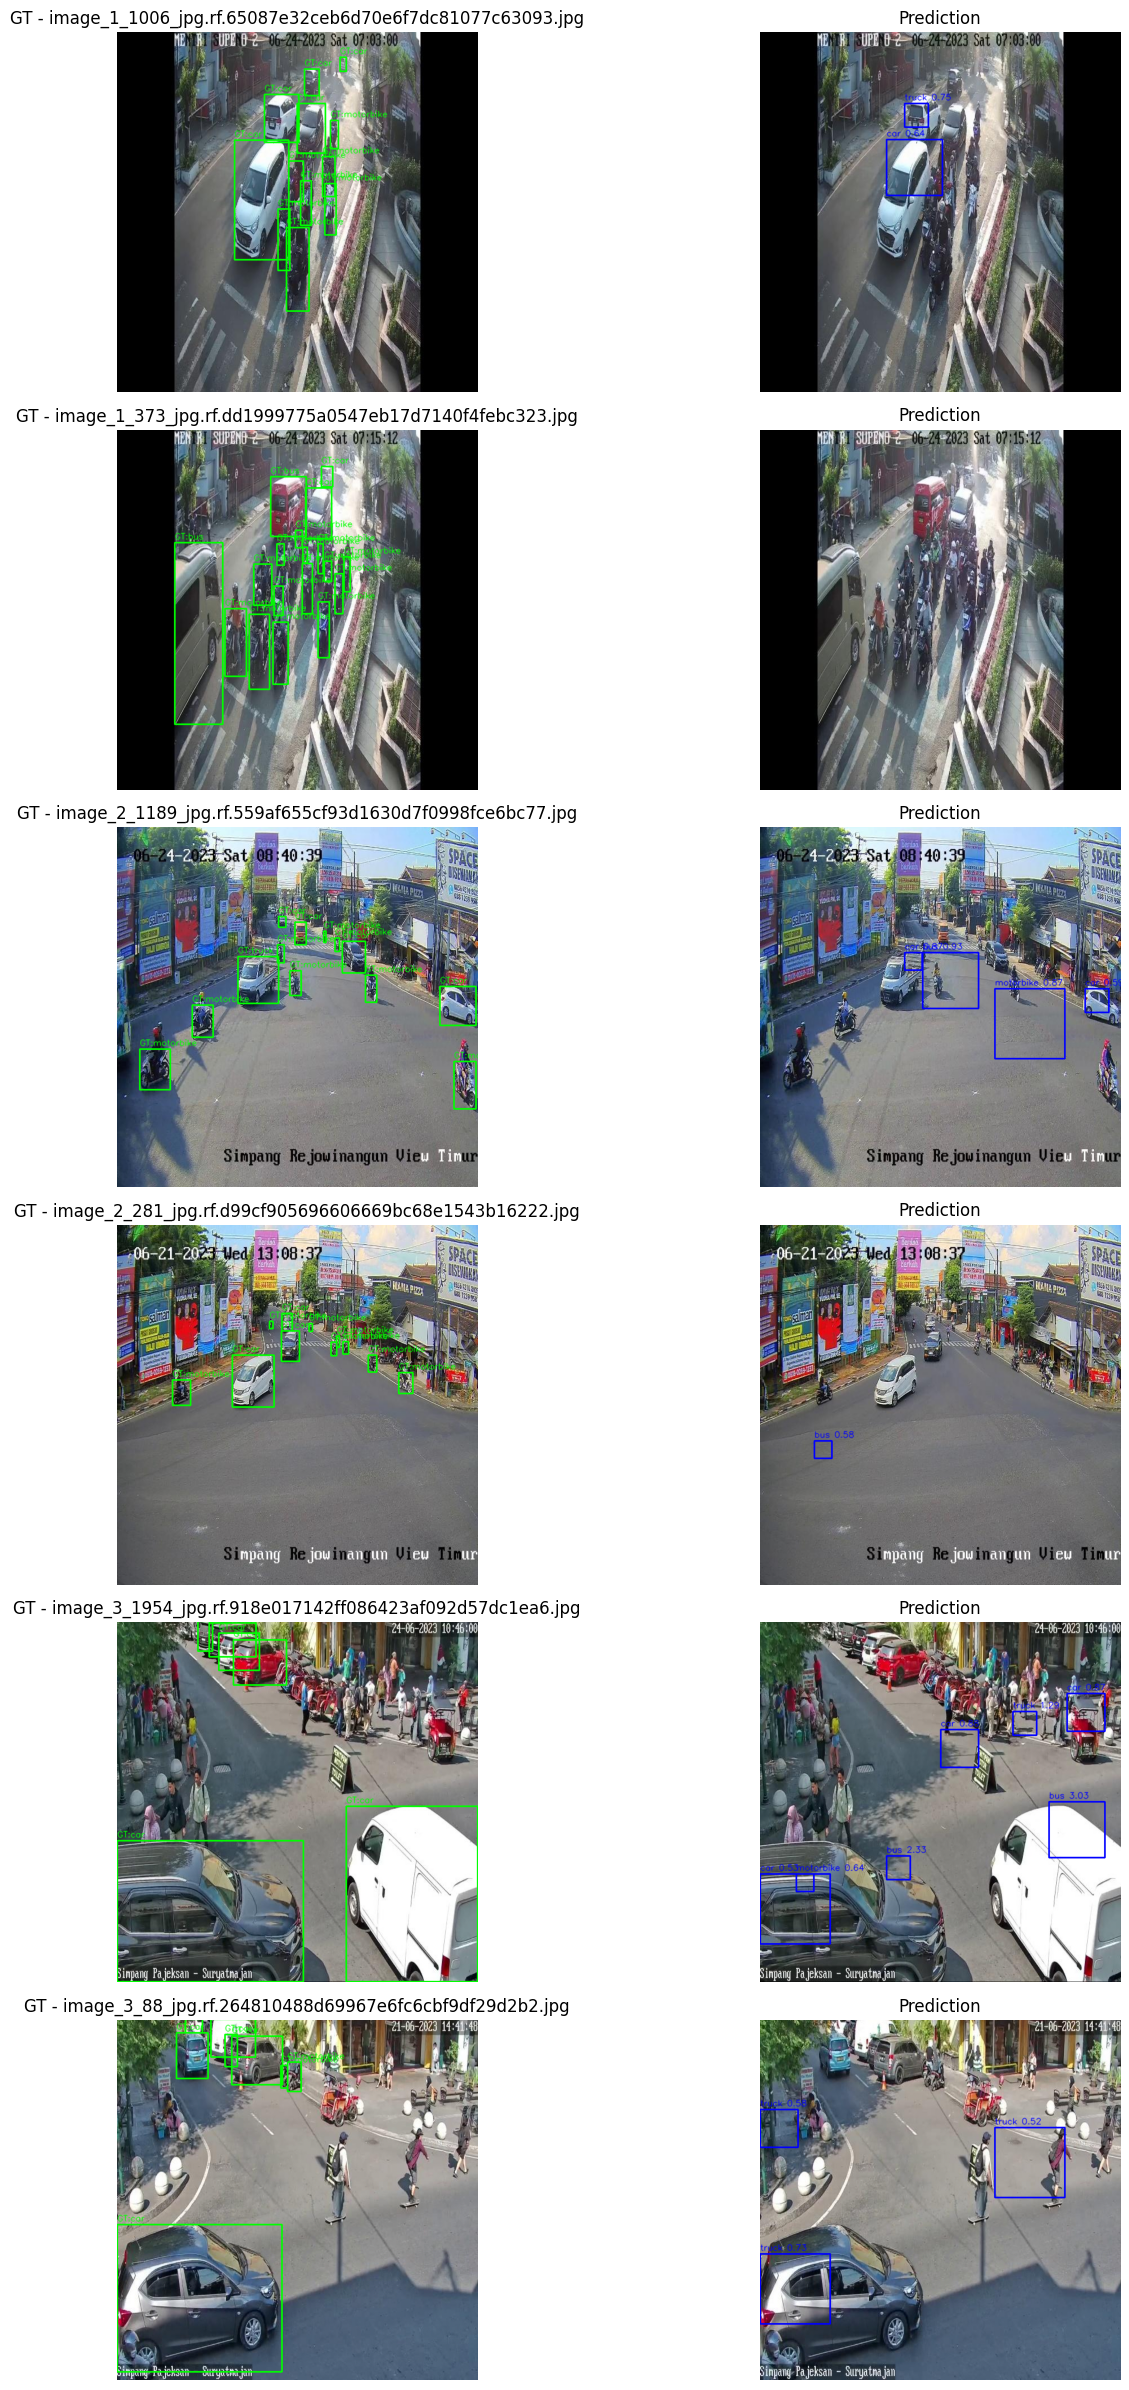

In [22]:
# Hàm vẽ bounding box
def draw_box(img, box, color, text=None):
    x1, y1, x2, y2 = [int(round(v)) for v in box]
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    if text:
        cv2.putText(img, text, (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

# Hàm hiển thị dự đoán cho ảnh
def show_predictions(records, results, k=6):
    k = min(k, len(records))
    idxs = np.linspace(0, len(records) - 1, k, dtype=int)
    plt.figure(figsize=(16, 4 * k))
    p = 1
    for idx in idxs:
        rec = records[idx]
        img = cv2.imread(str(rec['image_path']))
        if img is None:
            continue

        gt_img = img.copy()
        for b, l in zip(rec['boxes'], rec['labels']):
            draw_box(gt_img, b, (0, 255, 0), f'GT:{CLASS_NAMES[int(l)]}')

        pr_img = img.copy()
        for pr in results['preds_by_image'].get(idx, []):
            draw_box(pr_img, pr['box'], (255, 0, 0), f"{CLASS_NAMES[pr['label']]} {pr['score']:.2f}")

        plt.subplot(k, 2, p)
        plt.imshow(cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB))
        plt.title(f'GT - {rec["image_path"].name}')
        plt.axis('off')
        p += 1

        plt.subplot(k, 2, p)
        plt.imshow(cv2.cvtColor(pr_img, cv2.COLOR_BGR2RGB))
        plt.title('Prediction')
        plt.axis('off')
        p += 1

    plt.tight_layout()
    plt.show()

show_predictions(test_records, results_hn, k=6)

## If Metrics Are Still Low

1. Lower `SCORE_THRESHOLD` to 0.70 for higher recall.
2. Increase `WINDOW_STRIDE` to 32 for faster inference.
3. Add a second hard-negative mining round.